Analyzing after user turn 2/16...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 2: Entropy = 4.564
Analyzing after user turn 4/16...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 4: Entropy = 4.054
Analyzing after user turn 6/16...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 6: Entropy = 4.023
Analyzing after user turn 8/16...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 8: Entropy = 4.183
Analyzing after user turn 10/16...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 10: Entropy = 4.004
Analyzing after user turn 12/16...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 12: Entropy = 4.054
Analyzing after user turn 14/16...
  Sampl

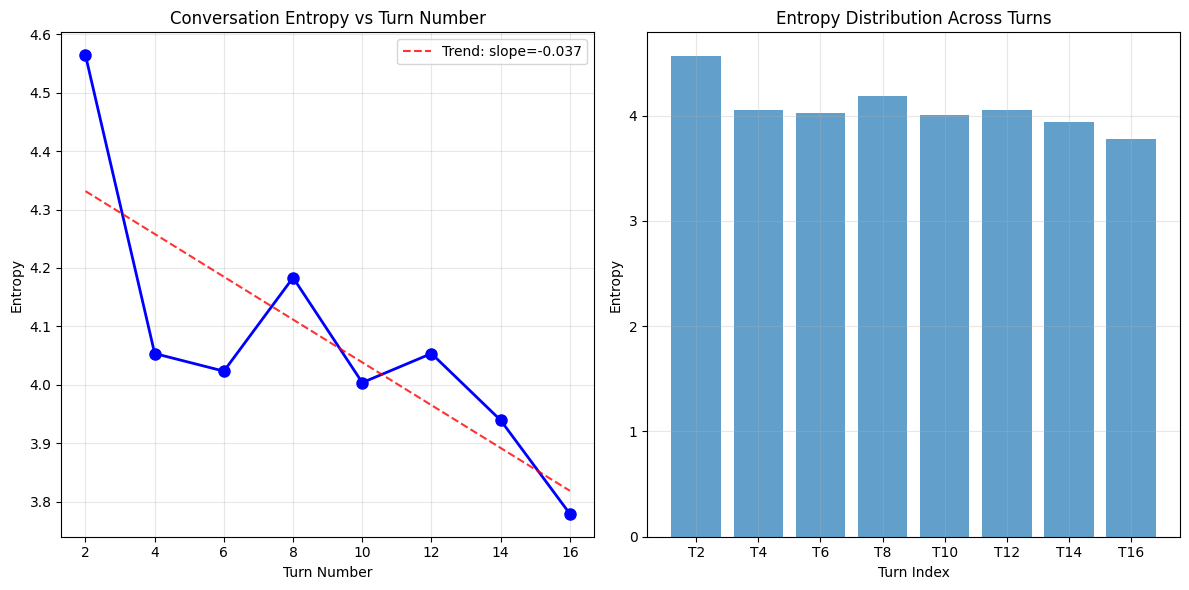


Summary Statistics:
Average entropy: 4.075
Standard deviation: 0.214
Min entropy: 3.779
Max entropy: 4.564
Correlation with turn number: -0.785


In [17]:
import boto3
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import re
from typing import List, Dict, Tuple
import time

class ConversationEntropyAnalyzer:
    def __init__(self, region_name='us-east-1', model_id='us.meta.llama3-1-8b-instruct-v1:0'):
        """
        Initialize the analyzer with Bedrock client
        
        Args:
            region_name: AWS region
            model_id: Bedrock model ID to use
        """
        self.bedrock_runtime = boto3.client('bedrock-runtime', region_name=region_name)
        self.model_id = model_id
        
    def format_conversation(self, conversation: List[Dict], up_to_turn: int) -> str:
        """
        Format conversation history up to a specific turn
        
        Args:
            conversation: List of conversation turns
            up_to_turn: Index of the last turn to include
            
        Returns:
            Formatted conversation string
        """
        formatted = ""
        for i, turn in enumerate(conversation[:up_to_turn + 1]):
            role = turn['role'].capitalize()
            content = turn['content'].replace('QUOTATION_MARK', '"')
            formatted += f"{role}: {content}\n"
        return formatted.strip()
    
    def call_llm(self, conversation_history: str) -> str:
        """
        Call the LLM on Bedrock with conversation history
        
        Args:
            conversation_history: Formatted conversation string
            
        Returns:
            LLM response
        """
        prompt = f"""Given the following conversation history:

                {conversation_history}

                Generate a list of the top 5 movies the user would like to watch based on this conversation. Format your response as a numbered list with no extra sentences:

                1. [First movie]
                2. [Second movie]
                3. [Third movie]
                4. [Fourth movie]
                5. [Fifth movie]

                Make sure each recommendation is distinct and plausible given the conversation context."""

        body = {
                "prompt": prompt,
                "max_gen_len": 1000,
                "temperature": 0.7,
                "top_p": 0.9
                }
        
        try:
            response = self.bedrock_runtime.invoke_model(
                modelId=self.model_id,
                body=json.dumps(body),
                contentType='application/json'
            )
            
            response_body = json.loads(response["body"].read())
        
            # Extract and print the response text
            if "content" in response_body:
                # print(response_body["content"][0]["text"])
                return response_body["content"][0]["text"]
            else:
                # print(response_body)
                return response_body['generation']
            
        except Exception as e:
            print(f"Error calling LLM: {e}")
            return ""
    
    def extract_responses(self, llm_output: str) -> List[str]:
        """
        Extract the 5 responses from LLM output
        
        Args:
            llm_output: Raw LLM response
            
        Returns:
            List of extracted responses
        """
        lines = llm_output.strip().split('\n')
        responses = []
        
        for line in lines:
            # Look for numbered list items
            match = re.match(r'^\d+\.\s*(.+)', line.strip())
            if match:
                responses.append(match.group(1).strip())
        
        # If we didn't get exactly 5, try alternative parsing
        if len(responses) != 5:
            # Try to split by numbers and clean up
            parts = re.split(r'\d+\.', llm_output)
            responses = [part.strip() for part in parts if part.strip()]
            
        return responses[:5]  # Take first 5 regardless
    
    def calculate_entropy(self, responses: List[str]) -> float:
        """
        Calculate entropy based on response similarity/diversity across the 5 samples
        
        Args:
            responses: List of response strings (should be 5 responses)
            
        Returns:
            Entropy value based on response diversity
        """
        if not responses or len(responses) < 2:
            return 0.0
        
        # Method 1: Calculate entropy based on response similarity
        # Convert responses to lowercase and strip whitespace for comparison
        cleaned_responses = [response.lower().strip() for response in responses]
        
        # Count frequency of each unique response
        response_counts = Counter(cleaned_responses)
        total_responses = len(cleaned_responses)
        
        # Calculate entropy based on response distribution
        entropy = 0.0
        for count in response_counts.values():
            probability = count / total_responses
            if probability > 0:
                entropy -= probability * np.log2(probability)
        
        return entropy
    
    def sample_and_calculate_entropy(self, conversation_history: str, num_samples: int = 5) -> float:
        """
        Sample multiple times and calculate entropy based on response diversity
        
        Args:
            conversation_history: Formatted conversation
            num_samples: Number of times to sample (should be 5)
            
        Returns:
            Entropy based on diversity across the 5 samples
        """
        all_responses = []
        
        for i in range(num_samples):
            print(f"  Sampling {i+1}/{num_samples}...")
            
            # Call LLM
            llm_output = self.call_llm(conversation_history)
            
            # Extract the 5 responses from this sample
            responses = self.extract_responses(llm_output)
            
            # Add all responses from this sample to our collection
            all_responses.extend(responses)
            
            # Small delay to avoid rate limiting
            # time.sleep(0.5)
        
        # Now calculate entropy across all responses from all samples
        # This measures how diverse the responses are across the 5 sampling runs
        return self.calculate_entropy(all_responses)
    
    def analyze_conversation(self, conversation: List[Dict], num_samples: int = 5) -> Tuple[List[int], List[float]]:
        """
        Analyze entropy across conversation turns
        
        Args:
            conversation: List of conversation turns
            num_samples: Number of samples per turn
            
        Returns:
            Tuple of (turn_numbers, entropy_values)
        """
        turn_numbers = []
        entropy_values = []
        
        # Only analyze after user turns (where we would predict assistant's next response)
        for i, turn in enumerate(conversation):
            if turn['role'] == 'user':
                print(f"Analyzing after user turn {i+1}/{len(conversation)}...")
                
                # Format conversation up to this turn (including the user's response)
                conversation_history = self.format_conversation(conversation, i)
                
                # Sample and calculate entropy for what the assistant might say next
                avg_entropy = self.sample_and_calculate_entropy(conversation_history, num_samples)
                
                turn_numbers.append(i + 1)
                entropy_values.append(avg_entropy)
                
                print(f"After user turn {i+1}: Entropy = {avg_entropy:.3f}")
        
        return turn_numbers, entropy_values
    
    def visualize_entropy(self, turn_numbers: List[int], entropy_values: List[float]):
        """
        Create visualization of entropy vs turn number
        
        Args:
            turn_numbers: List of turn numbers
            entropy_values: List of corresponding entropy values
        """
        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        plt.plot(turn_numbers, entropy_values, 'bo-', linewidth=2, markersize=8)
        plt.xlabel('Turn Number')
        plt.ylabel('Entropy')
        plt.title('Conversation Entropy vs Turn Number')
        plt.grid(True, alpha=0.3)
        
        # Add trend line
        if len(turn_numbers) > 1:
            z = np.polyfit(turn_numbers, entropy_values, 1)
            p = np.poly1d(z)
            plt.plot(turn_numbers, p(turn_numbers), "r--", alpha=0.8, label=f'Trend: slope={z[0]:.3f}')
            plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.bar(range(len(entropy_values)), entropy_values, alpha=0.7)
        plt.xlabel('Turn Index')
        plt.ylabel('Entropy')
        plt.title('Entropy Distribution Across Turns')
        plt.xticks(range(len(entropy_values)), [f'T{t}' for t in turn_numbers])
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print(f"\nSummary Statistics:")
        print(f"Average entropy: {np.mean(entropy_values):.3f}")
        print(f"Standard deviation: {np.std(entropy_values):.3f}")
        print(f"Min entropy: {np.min(entropy_values):.3f}")
        print(f"Max entropy: {np.max(entropy_values):.3f}")
        
        if len(entropy_values) > 1:
            correlation = np.corrcoef(turn_numbers, entropy_values)[0, 1]
            print(f"Correlation with turn number: {correlation:.3f}")


conversation2 = [{
        "role": "user",
        "content": "Can you help me find a movie?"
      },
      {
        "role": "assistant",
        "content": "I will try my best! What was the last movie you watched?"
      },
      {
        "role": "user",
        "content": "Skyscraper !"
      },
      {
        "role": "assistant",
        "content": "Oh that movie was awesome! I love The Rock."
      },
      {
        "role": "user",
        "content": "You've seen it?! It was SO good. I've actually seen it a few times. What was your favorite part?"
      },
      {
        "role": "assistant",
        "content": "I'm a tech nerd so the specs about the actual building, and then watching the tour of the building was amazing. The architecture was so detailed."
      },
      {
        "role": "user",
        "content": "It was ! I loved how they showed detail about the massive building as well. It truly was a beautiful building. Have you seen any good movies that are similar to Skyscraper?"
      },
      {
        "role": "assistant",
        "content": "Yes. I know of two big ones. They are a few years old. One is San Andreas which also features The Rock, and the other is any of the Die Hard movies."
      },
      {
        "role": "user",
        "content": "I've honestly never seen any of the Die Hard movies. What are they about?"
      },
      {
        "role": "assistant",
        "content": "The first one is about a man who is an NYPD officer. He has to save his wife and other hostages being held at Nakatomi Plaza in LA. There are lots of scenes with impossible rescues, and tons of action."
      },
      {
        "role": "user",
        "content": "That actually sounds really good! I'll have to check them out! Thank you so much for the recommendation"
      }]

conversation = [
    {
        "role": "assistant",
        "content": "Hi! I'm here to help you chose a movie!"
    },
    {
        "role": "user",
        "content": "Terrific"
    },
    {
        "role": "assistant",
        "content": "What are some genres you like? What was the last movie you saw?"
    },
    {
        "role": "user",
        "content": "the last movie i saw in the theater was QUOTATION_MARKHustlersQUOTATION_MARK . I generally like comedy, drama and documentaries"
    },
    {
        "role": "assistant",
        "content": "How did you like QUOTATION_MARKHustlersQUOTATION_MARK? It definitely has the drama aspect, did it leave you wanting more or was it not exactly what you were looking for?"
    },
    {
        "role": "user",
        "content": "I liked it,  it wasn't the most high-brow movie i've ever seen but it was fun. I like to just enjoy"
    },
    {
        "role": "assistant",
        "content": "And what are your thoughts on action in film?"
    },
    {
        "role": "user",
        "content": "I like some action. Just not too violent"
    },
    {
        "role": "assistant",
        "content": "Definitely, movies like QUOTATION_MARKDeadpoolQUOTATION_MARK wouldn't be up your alley I'm guessing?"
    },
    {
        "role": "user",
        "content": "It could be. I understand Deadpool was very funny  I like funny"
    },
    {
        "role": "assistant",
        "content": "Haha it definitely was, I think I have a suggestion for you though"
    },
    {
        "role": "user",
        "content": "Cool  Whats that?"
    },
    {
        "role": "assistant",
        "content": "So it's the newQUOTATION_MARKA Beautiful Day in the NeighborhoodQUOTATION_MARK, the Mr. Rogers movie with Tom Hanks as the actor. It's not as much a comedic relief, but I saw it in theatres with my roomates and it's honestly a super refreshing and incredibly well directed movie."
    },
    {
        "role": "user",
        "content": "that sounds so good to me. I loved Mr. Rogers so much.. and Tom Hanks is a great actor"
    },
    {
        "role": "assistant",
        "content": "The combination is incredible to be honest, and it lets you understand his background and who he was as a person so much more"
    },
    {
        "role": "user",
        "content": "That sounds amazing. I would love to see that"
    }
]

# Initialize analyzer
analyzer = ConversationEntropyAnalyzer()

# Analyze conversation
turn_numbers, entropy_values = analyzer.analyze_conversation(conversation, num_samples=5)

# Visualize results
analyzer.visualize_entropy(turn_numbers, entropy_values)


Analyzing after user turn 1/19...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 1: Entropy = 3.907
Analyzing after user turn 3/19...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 3: Entropy = 3.335
Analyzing after user turn 5/19...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 5: Entropy = 3.916
Analyzing after user turn 7/19...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 7: Entropy = 3.859
Analyzing after user turn 9/19...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 9: Entropy = 4.103
Analyzing after user turn 11/19...
  Sampling 1/5...
  Sampling 2/5...
  Sampling 3/5...
  Sampling 4/5...
  Sampling 5/5...
After user turn 11: Entropy = 3.719
Analyzing after user turn 13/19...
  Samplin

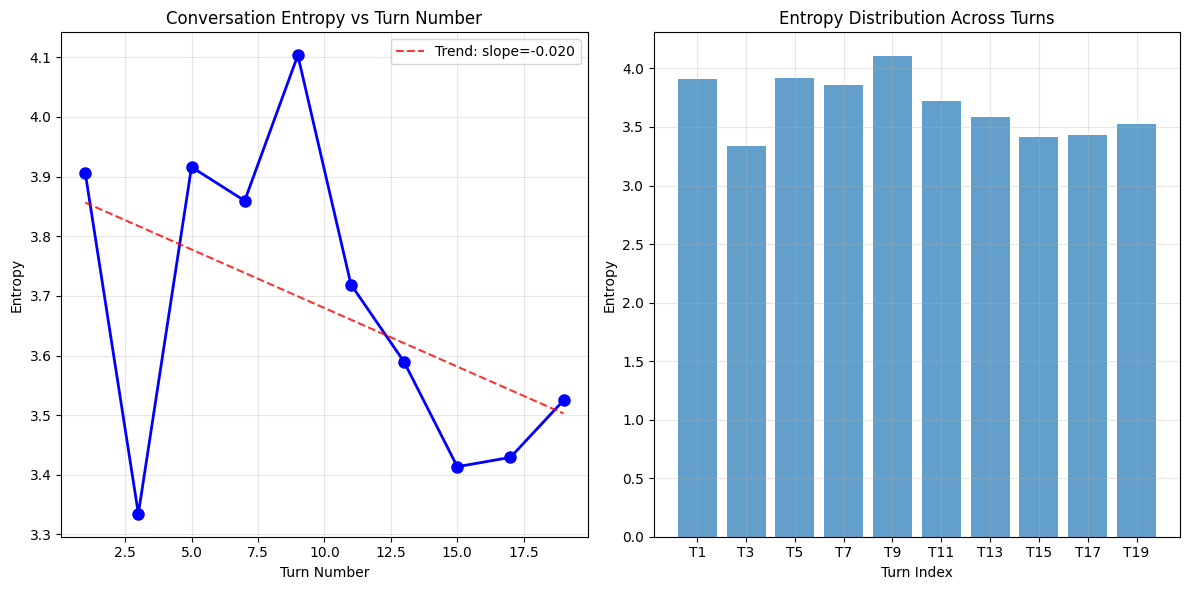


Summary Statistics:
Average entropy: 3.680
Standard deviation: 0.246
Min entropy: 3.335
Max entropy: 4.103
Correlation with turn number: -0.459


In [18]:
turn_numbers2, entropy_values2 = analyzer.analyze_conversation(conversation2, num_samples=5)

# Visualize results
analyzer.visualize_entropy(turn_numbers2, entropy_values2)